### 4. Multilocus simulators
#### 4.1 autosomes
Now we can simulate a bunch of <code>L</code> independent loci in one go. Note that the outputs become matrices with <code>L</code> rows of allele frequencies. 

Note: R hates loops. This multilocus simulator should be much faster than looping the single-locus version <code>L</code> times. You may use <code>system.time()</code> to benchmark. 

CHECK MY CODES FOR POTENTIAL BUGS!

In [1]:
sim_multi_autosomes<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, t=10)
{
    # INITIALISATION
    # EMPTY MATRICES. pop1m = ALLELE FREQ OF MALES IN POP1. COLUMNS = TIME. ROWS = LOCI
    pop1m<-matrix(NA, nr=L, nc=t+1)
    pop1f<-matrix(NA, nr=L, nc=t+1)
    pop2m<-matrix(NA, nr=L, nc=t+1)
    pop2f<-matrix(NA, nr=L, nc=t+1)
    # INITIAL FREQ, ALL AROUND 0.5?
    pop1m[,1]<-runif(L, 0.4, 0.6)
    pop1f[,1]<-pop1m[,1]
    pop2m[,1]<-pop1m[,1]
    pop2f[,1]<-pop1m[,1]
    # PROPAGATION
    for (i in 1:t)
    {
        # NEW GAMETE POOL FREQ FOR THE DIFFERENT COMPARTMENTS, AFTER MIGRATION
        gametem<-Mm%*%rbind(pop1m[,i], pop2m[,i])
        gametef<-Mf%*%rbind(pop1f[,i], pop2f[,i])
        # SAMPLING OFFSPRING. FROM MALE AND FEMALE PARENTS
        pop1m[,i+1]<-(rbinom(L, size=Nm[1], prob=gametem[1,])+rbinom(L, size=Nm[1], prob=gametef[1,]))/(2*Nm[1])
        pop1f[,i+1]<-(rbinom(L, size=Nf[1], prob=gametem[1,])+rbinom(L, size=Nf[1], prob=gametef[1,]))/(2*Nf[1])
        pop2m[,i+1]<-(rbinom(L, size=Nm[2], prob=gametem[2,])+rbinom(L, size=Nm[2], prob=gametef[2,]))/(2*Nm[2])
        pop2f[,i+1]<-(rbinom(L, size=Nf[2], prob=gametem[2,])+rbinom(L, size=Nf[2], prob=gametef[2,]))/(2*Nf[2])
    }
    # RETURN ALL THE ALLELE FREQ
    return(list(pop1m=pop1m, pop1f=pop1f, pop2m=pop2m, pop2f=pop2f))
}

   user  system elapsed 
   0.08    0.00    0.08 

[1] 500  41

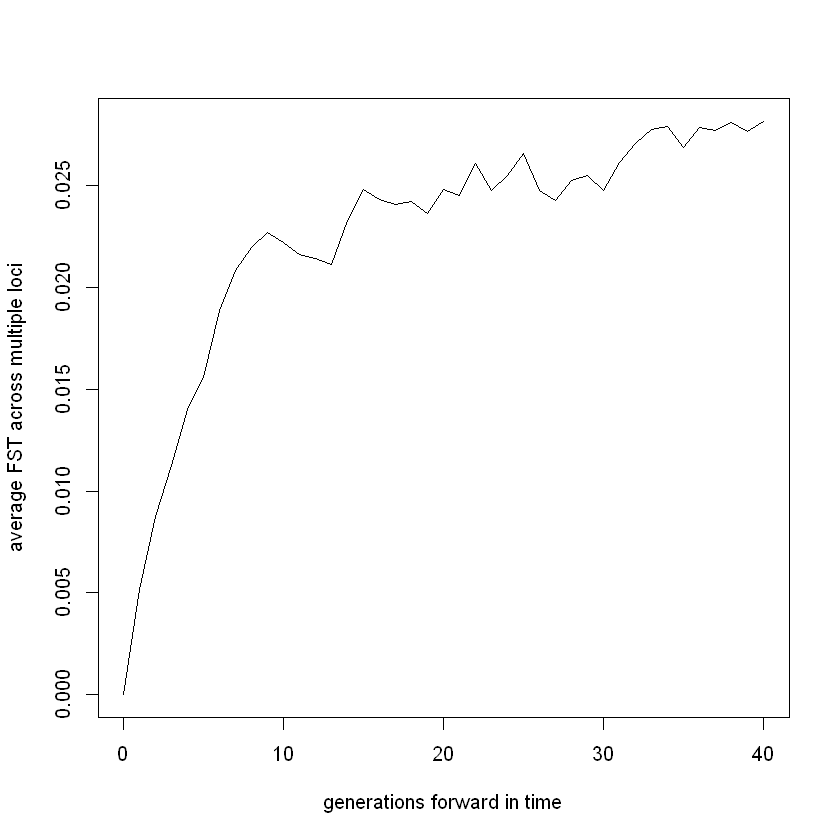

In [2]:
# TEST RUN
system.time(temp<-sim_multi_autosomes(t=40))
p1<-(temp$pop1m+temp$pop1f)/2
p2<-(temp$pop2m+temp$pop2f)/2
p<-(p1+p2)/2
dim(temp$pop1m)
FST<-apply((p1-p2)^2/(p*(1-p)), 2, mean, na.rm=T)
plot(0:40, FST, type='l', 
     xlab='generations forward in time', ylab='average FST across multiple loci')

In [3]:
sim_multi_X<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, t=10)
{
    # INITIALISATION
    # EMPTY MATRICES. pop1m = ALLELE FREQ OF MALES IN POP1. COLUMNS = TIME. ROWS = LOCI
    pop1m<-matrix(NA, nr=L, nc=t+1)
    pop1f<-matrix(NA, nr=L, nc=t+1)
    pop2m<-matrix(NA, nr=L, nc=t+1)
    pop2f<-matrix(NA, nr=L, nc=t+1)
    # INITIAL FREQ, ALL AROUND 0.5?
    pop1m[,1]<-runif(L, 0.4, 0.6)
    pop1f[,1]<-pop1m[,1]
    pop2m[,1]<-pop1m[,1]
    pop2f[,1]<-pop1m[,1]
    # PROPAGATION
    for (i in 1:t)
    {
        # NEW GAMETE POOL FREQ FOR THE DIFFERENT COMPARTMENTS, AFTER MIGRATION
        gametem<-Mm%*%rbind(pop1m[,i], pop2m[,i])
        gametef<-Mf%*%rbind(pop1f[,i], pop2f[,i])
        # SAMPLING OFFSPRING
        pop1m[,i+1]<-rbinom(L, size=Nm[1], prob=gametef[1,])/Nm[1]
        pop1f[,i+1]<-(rbinom(L, size=Nf[1], prob=gametem[1,])+rbinom(L, size=Nf[1], prob=gametef[1,]))/(2*Nf[1])
        pop2m[,i+1]<-rbinom(L, size=Nm[2], prob=gametef[2,])/Nm[2]
        pop2f[,i+1]<-(rbinom(L, size=Nf[2], prob=gametem[2,])+rbinom(L, size=Nf[2], prob=gametef[2,]))/(2*Nf[2])
    }
    return(list(pop1m=pop1m, pop1f=pop1f, pop2m=pop2m, pop2f=pop2f))
}

### 5. Multilocus + sampling
#### 5.1 autosomes
With extra arguments <code>nm</code> and <code>nf</code>. 

In [6]:
sim_multi_autosomes_sample<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, nm=c(50, 50), nf=c(50, 50), t=10)
{
    # REUSE
    temp<-sim_multi_autosomes(Nm=Nm, Nf=Nf, Mm=Mm, Mf=Mf, L=L, t=t)
    # BINOMIAL SAMPLING
    temp1<-list()
    temp1$pop1m<-matrix(rbinom(L*(t+1), size=2*nm[1], prob=temp$pop1m)/(2*nm[1]), nc=L)
    temp1$pop1f<-matrix(rbinom(L*(t+1), size=2*nf[1], prob=temp$pop1f)/(2*nf[1]), nc=L)
    temp1$pop2m<-matrix(rbinom(L*(t+1), size=2*nm[2], prob=temp$pop2m)/(2*nm[2]), nc=L)
    temp1$pop2f<-matrix(rbinom(L*(t+1), size=2*nf[2], prob=temp$pop2f)/(2*nf[2]), nc=L)
    return(temp1)
}

#### 5.2 X

In [ ]:
sim_multi_X_sample<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, nm=c(50, 50), nf=c(50, 50), t=10)
{
    # REUSE
    temp<-sim_multi_X(Nm=Nm, Nf=Nf, Mm=Mm, Mf=Mf, L=L, t=t)
    # BINOMIAL SAMPLING
    temp1<-list()
    temp1$pop1m<-matrix(rbinom(L*(t+1), size=nm[1], prob=temp$pop1m)/nm[1], nc=L)
    temp1$pop1f<-matrix(rbinom(L*(t+1), size=2*nf[1], prob=temp$pop1f)/(2*nf[1]), nc=L)
    temp1$pop2m<-matrix(rbinom(L*(t+1), size=nm[2], prob=temp$pop1m)/nm[2], nc=L)
    temp1$pop2f<-matrix(rbinom(L*(t+1), size=2*nf[2], prob=temp$pop1f)/(2*nf[2]), nc=L)
    return(temp1)
}